# Power Demand Forecasting - EDA & Modeling
### Apex Power & Utilities | Dhanbad, Jharkhand (132 KV feeders F1, F2, F3)

**Assignment 1 - Milestone 1 (EDA) + Milestone 2 (Feature Engineering & Model Justification)**

---

## 1. Problem framing

Apex Power & Utilities operates **three 132 KV feeders** (`F1`, `F2`, `F3`) supplying the
Dhanbad coal-and-steel belt of Jharkhand, India. The grid operator needs a **day-ahead
demand forecast** so it can schedule generation/purchase, manage load, and avoid both
under-supply (load shedding) and over-supply (wasted, costly power).

**Concrete prediction target.** Readings arrive every **10 minutes**, i.e.
**144 ten-minute blocks per day** (`24 h x 60 / 10 = 144`). For *any chosen future day* we
must predict the power consumption of each feeder for all 144 blocks, and therefore the
**total system load** (`F1 + F2 + F3`) for those 144 blocks.

**Why this is hard / interesting.**
- The raw timestamps come in **two different, interleaved date formats** (a real data-quality trap).
- Demand has **strong multi-scale seasonality**: daily (industrial + domestic cycle),
  weekly (weekday vs weekend), and annual/seasonal (winter heating vs summer cooling).
- It is sensitive to **weather** (temperature, humidity, wind) and to **localized holidays**
  - in an industrial belt a *festival* or an *industrial* holiday like **Vishwakarma Puja**
  visibly changes the load shape, and these are **Jharkhand-specific**, not on a generic
  national calendar.

**This notebook tells the end-to-end story:** raw data -> the mixed-format problem ->
EDA on load / weather / holidays -> cleaning -> feature engineering -> model choice
justification -> training, validation, and feature importance. Where it helps, we import
the already-built, production `src/` modules (the same code the API and dashboard run on),
so the notebook documents the *actual* pipeline rather than a throwaway reimplementation.

In [1]:
# Standard scientific stack + the project's own production modules (src/).
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Make sure the project root is importable so `import src...` resolves whether
# the notebook is executed from notebooks/ or from the project root.
import os, sys
_here = os.getcwd()
_root = _here if os.path.isdir(os.path.join(_here, "src")) else os.path.dirname(_here)
if _root not in sys.path:
    sys.path.insert(0, _root)

from src import config
from src.data_cleaning import load_raw, clean_load_data, parse_datetime_series
from src.features import build_features, FEATURE_COLUMNS
from src.holidays_data import load_holidays, get_holidays, holiday_flags_for_index

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Location :", config.LOCATION, f"(lat={config.LAT}, lon={config.LON})")
print("Feeders  :", config.FEEDERS, "->", config.FEEDER_COLS)
print("Cadence  :", f"{config.INTERVAL_MIN} min  ->  {config.BLOCKS_PER_DAY} blocks/day  "
      f"(default horizon {config.HORIZON_HOURS} h)")
print("Raw CSV  :", config.RAW_CSV.name, "| Holidays:", config.HOLIDAYS_CSV.name)

Location : Dhanbad, Jharkhand, India (lat=23.7957, lon=86.4304)
Feeders  : ['F1', 'F2', 'F3'] -> {'F1': 'F1_132KV_PowerConsumption', 'F2': 'F2_132KV_PowerConsumption', 'F3': 'F3_132KV_PowerConsumption'}
Cadence  : 10 min  ->  144 blocks/day  (default horizon 24 h)
Raw CSV  : Utility_consumption.csv | Holidays: holidays_dhanbad.csv


## 2. Load the raw data and surface the **mixed date-format** problem

The very first thing to notice in `Utility_consumption.csv` is that the `Datetime` column is
**not** in one consistent format. Some rows use **day-first with dashes** (`DD-MM-YYYY HH:MM`)
and some use **month-first with slashes** (`MM/DD/YYYY HH:MM`), and the slash rows even use
**non-zero-padded hours** (`0:00` instead of `00:00`). Crucially, the two formats are
**interleaved** across the year, not split cleanly into an early and a late block.

If you naively call `pd.to_datetime` on this column, pandas will silently *misparse* rows -
e.g. `01-02-2017` becomes 1 Feb under one assumption but 2 Jan under another - corrupting the
time axis that *everything else* (seasonality, daily profiles, the model) depends on.

In [2]:
# Load the raw CSV as plain strings first so we can SEE the two formats untouched.
raw_str = pd.read_csv(config.RAW_CSV, dtype={"Datetime": str})
print("Raw shape:", raw_str.shape)
print("Columns  :", list(raw_str.columns))
raw_str.head(3)

Raw shape: (52416, 7)
Columns  : ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption']


,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373


In [3]:
# Classify each row purely by its date separator (the disambiguation rule).
s = raw_str["Datetime"].astype(str).str.strip()
is_slash = s.str.contains("/", regex=False)
is_dash  = s.str.contains("-", regex=False) & ~is_slash

n_dash, n_slash = int(is_dash.sum()), int(is_slash.sum())
print(f"DASH  rows  'DD-MM-YYYY HH:MM' : {n_dash:>6}  ({n_dash/len(s):.1%})")
print(f"SLASH rows  'MM/DD/YYYY HH:MM' : {n_slash:>6}  ({n_slash/len(s):.1%})")
print()
print("Examples of each format (note slash rows use non-padded hours like '0:00'):")
print("  DASH  ->", s[is_dash].head(3).tolist())
print("  SLASH ->", s[is_slash].head(3).tolist())

DASH  rows  'DD-MM-YYYY HH:MM' :  20736  (39.6%)
SLASH rows  'MM/DD/YYYY HH:MM' :  31680  (60.4%)

Examples of each format (note slash rows use non-padded hours like '0:00'):
  DASH  -> ['01-01-2017 00:00', '01-01-2017 00:10', '01-01-2017 00:20']
  SLASH -> ['1/13/2017 0:00', '1/13/2017 0:10', '1/13/2017 0:20']


In [4]:
# PROOF that the two formats are INTERLEAVED across the year, not split early/late.
# Parse with the correct format per group, then look at the date RANGE each spans.
dash_dt  = pd.to_datetime(s[is_dash],  format="%d-%m-%Y %H:%M", errors="coerce")
slash_dt = pd.to_datetime(s[is_slash], format="%m/%d/%Y %H:%M", errors="coerce")

print(f"DASH  rows span  : {dash_dt.min().date()}  ->  {dash_dt.max().date()}")
print(f"SLASH rows span  : {slash_dt.min().date()}  ->  {slash_dt.max().date()}")
print()
print("Both ranges overlap heavily (Jan -> Dec), proving the formats are interleaved.")
print("=> a single pd.to_datetime() guess is unreliable; the separator rule is robust.")

DASH  rows span  : 2017-01-01  ->  2017-12-12
SLASH rows span  : 2017-01-13  ->  2017-12-30

Both ranges overlap heavily (Jan -> Dec), proving the formats are interleaved.
=> a single pd.to_datetime() guess is unreliable; the separator rule is robust.


In [5]:
# Demonstrate the FAILURE of a naive single-format parse vs parse_datetime_series().
naive = pd.to_datetime(raw_str["Datetime"], errors="coerce", dayfirst=True)
robust = parse_datetime_series(raw_str["Datetime"])

print("Naive  pd.to_datetime(dayfirst=True): NaT (unparsed) =", int(naive.isna().sum()))
print("Robust parse_datetime_series()      : NaT (unparsed) =", int(robust.isna().sum()))
print()

# Show a concrete row where naive parsing changes the actual calendar date.
demo_idx = s[is_slash].index[0]   # first slash row, e.g. '1/13/2017 0:00'
print("Raw string         :", raw_str.loc[demo_idx, 'Datetime'])
print("Naive (dayfirst)   :", naive.loc[demo_idx], " <- WRONG month/day swap risk")
print("Separator-based     :", robust.loc[demo_idx], " <- correct (month-first for '/')")

Naive  pd.to_datetime(dayfirst=True): NaT (unparsed) = 31680
Robust parse_datetime_series()      : NaT (unparsed) = 0

Raw string         : 1/13/2017 0:00
Naive (dayfirst)   : NaT  <- WRONG month/day swap risk
Separator-based     : 2017-01-13 00:00:00  <- correct (month-first for '/')


**Takeaway.** `parse_datetime_series` resolves the ambiguity deterministically by the *separator*:
a `-` -> day-first (`%d-%m-%Y %H:%M`), a `/` -> month-first (`%m/%d/%Y %H:%M`). This recovers a
clean, monotone time axis with **zero** unparseable rows - the foundation for every plot below.

## 3. EDA on the load (feeder power consumption)

We now attach the robustly-parsed datetime and explore the *raw* feeder series **before**
cleaning - so we can let the data tell us what cleaning is actually needed. We look at
summary statistics, per-feeder distributions, the time series itself, the **average daily
load profile** (by 10-minute block-of-day), **weekday vs weekend**, **monthly/seasonal**
patterns, and we explicitly quantify **outliers / zeros / negatives / gaps**.

In [6]:
# Build a raw, datetime-indexed frame (parsed but NOT yet cleaned).
raw = load_raw()                       # production loader: adds parsed 'Datetime'
raw = raw.dropna(subset=["Datetime"]).sort_values("Datetime").set_index("Datetime")

feeder_cols = list(config.FEEDER_COLS.values())     # the 3 feeder columns
raw["TOTAL"] = raw[feeder_cols].sum(axis=1)         # system load = F1+F2+F3

print("Time span :", raw.index.min(), "->", raw.index.max())
print("Rows      :", len(raw))
print()
print("Feeder + total summary statistics (kW):")
raw[feeder_cols + ["TOTAL"]].describe().round(1)

Time span : 2017-01-01 00:00:00 -> 2017-12-30 23:50:00
Rows      : 52416

Feeder + total summary statistics (kW):


,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,TOTAL
count,52416.0,52416.0,52416.0,52416.0
mean,32345.0,21042.5,17835.4,71222.9
std,7130.6,5201.5,6622.2,17143.1
min,13895.7,8560.1,5935.2,36785.0
25%,26310.7,16980.8,13129.3,56499.1
50%,32265.9,20823.2,16415.1,69788.8
75%,37309.0,24713.7,21624.1,83749.2
max,52204.4,37408.9,47598.3,134208.1


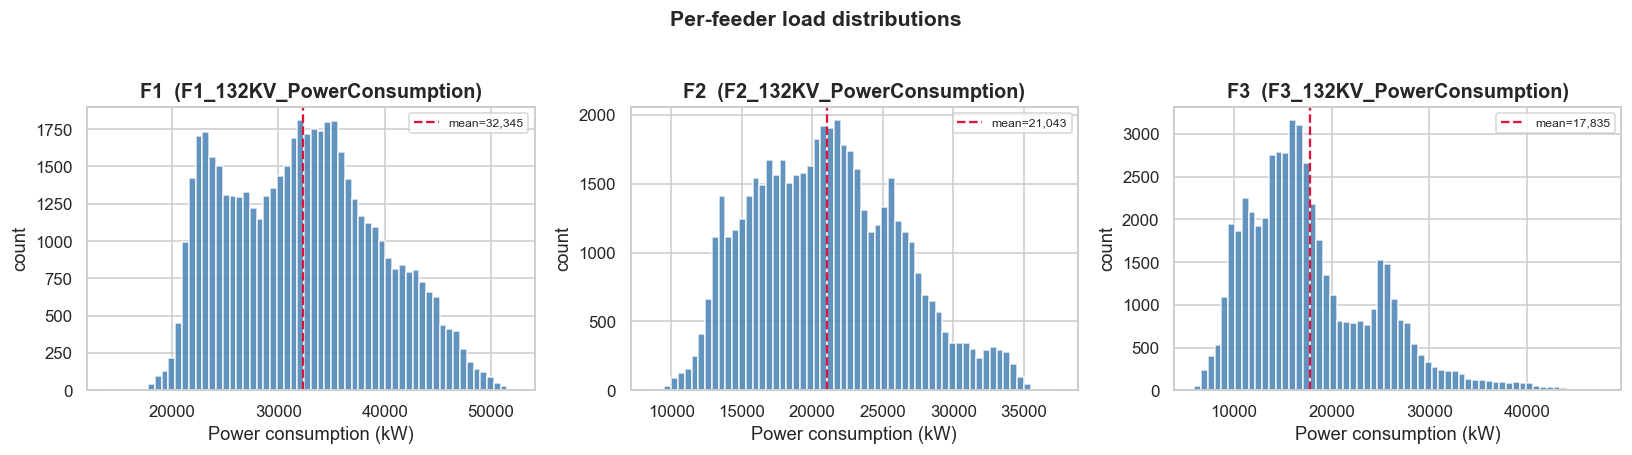

F1 is the largest feeder; F2 and F3 are smaller. All three are unimodal-ish with
a right tail, consistent with industrial base load + variable demand peaks.


In [7]:
# Per-feeder distributions (histograms) to compare scale and spread.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, config.FEEDERS):
    col = config.FEEDER_COLS[f]
    ax.hist(raw[col], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(raw[col].mean(), color="crimson", ls="--", lw=1.5,
               label=f"mean={raw[col].mean():,.0f}")
    ax.set_title(f"{f}  ({col})")
    ax.set_xlabel("Power consumption (kW)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
fig.suptitle("Per-feeder load distributions", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("F1 is the largest feeder; F2 and F3 are smaller. All three are unimodal-ish with"
      "\na right tail, consistent with industrial base load + variable demand peaks.")

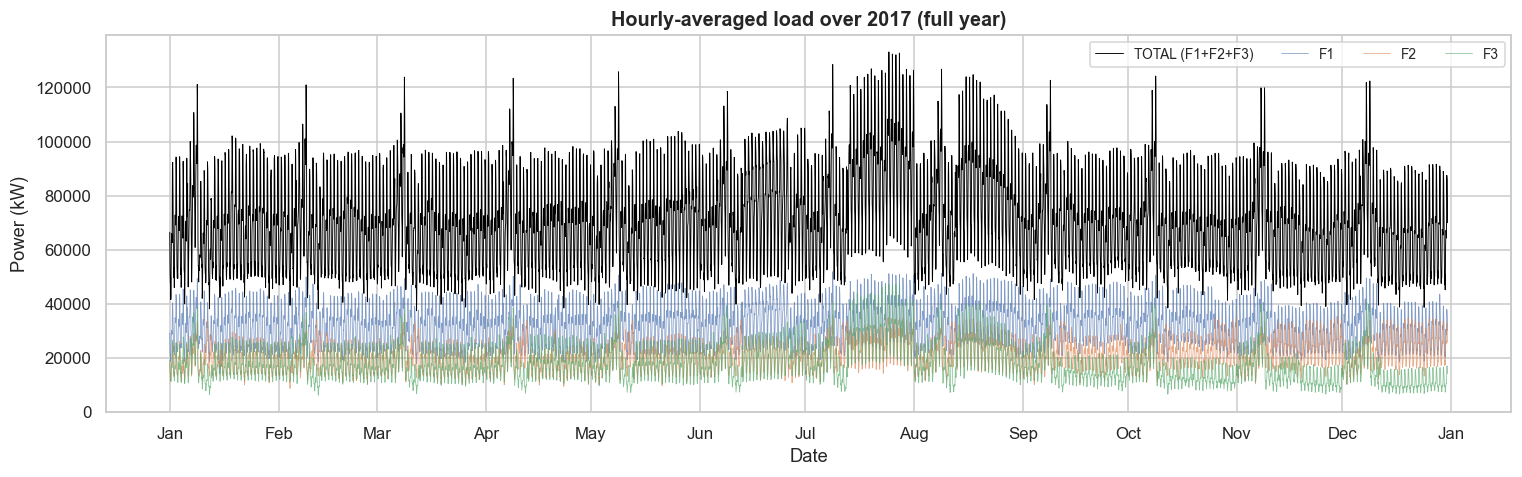

Visible: a clear annual envelope (lower in mid-year monsoon/summer, higher in the
cool winter months) plus dense high-frequency daily oscillation -> strong seasonality.


In [8]:
# Full-year time series of total load + each feeder (downsampled to hourly for clarity).
hourly = raw[feeder_cols + ["TOTAL"]].resample("1h").mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(hourly.index, hourly["TOTAL"], color="black", lw=0.6, label="TOTAL (F1+F2+F3)")
for f, c in zip(config.FEEDERS, ["#1f77b4", "#2ca02c", "#d62728"]):
    ax.plot(hourly.index, hourly[config.FEEDER_COLS[f]], lw=0.5, alpha=0.7, label=f)
ax.set_title("Hourly-averaged load over 2017 (full year)")
ax.set_xlabel("Date"); ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

print("Visible: a clear annual envelope (lower in mid-year monsoon/summer, higher in the"
      "\ncool winter months) plus dense high-frequency daily oscillation -> strong seasonality.")

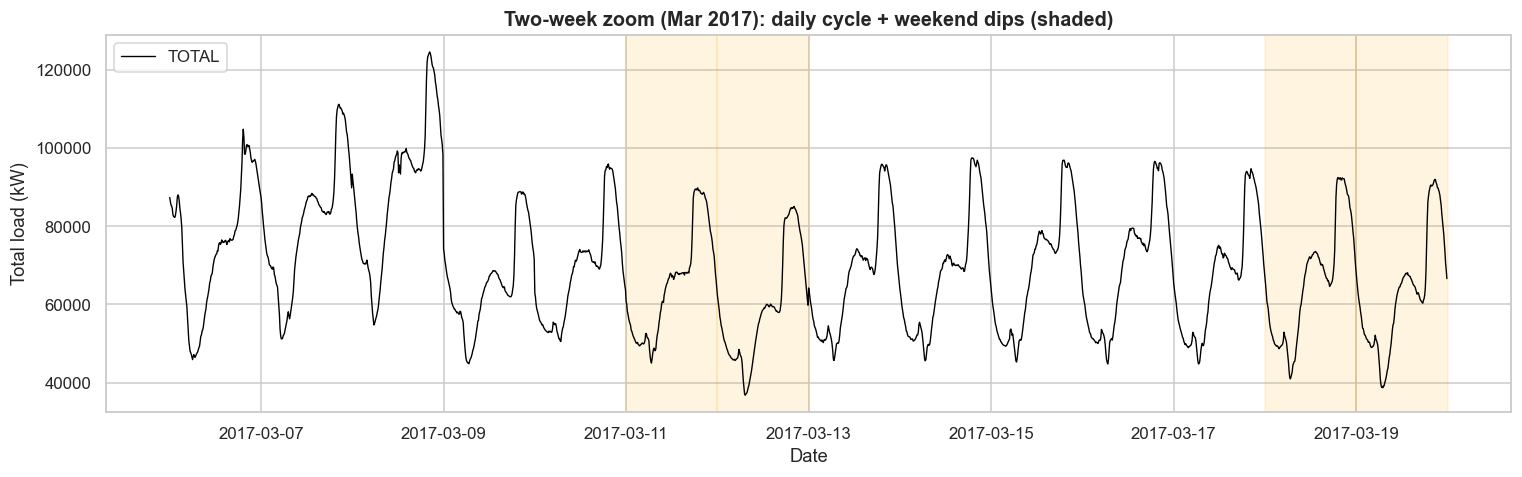

Each day shows a repeatable intraday shape; shaded weekends sit visibly lower -> the
model must learn both block-of-day and day-of-week structure.


In [9]:
# Zoom into two representative weeks to expose the DAILY + WEEKLY cycle clearly.
win = raw.loc["2017-03-06":"2017-03-19", feeder_cols + ["TOTAL"]]
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(win.index, win["TOTAL"], color="black", lw=0.9, label="TOTAL")
# Shade weekends.
for day in pd.date_range("2017-03-06", "2017-03-19", freq="D"):
    if day.dayofweek >= 5:
        ax.axvspan(day, day + pd.Timedelta(days=1), color="orange", alpha=0.12)
ax.set_title("Two-week zoom (Mar 2017): daily cycle + weekend dips (shaded)")
ax.set_xlabel("Date"); ax.set_ylabel("Total load (kW)")
ax.legend()
plt.tight_layout()
plt.show()

print("Each day shows a repeatable intraday shape; shaded weekends sit visibly lower -> the"
      "\nmodel must learn both block-of-day and day-of-week structure.")

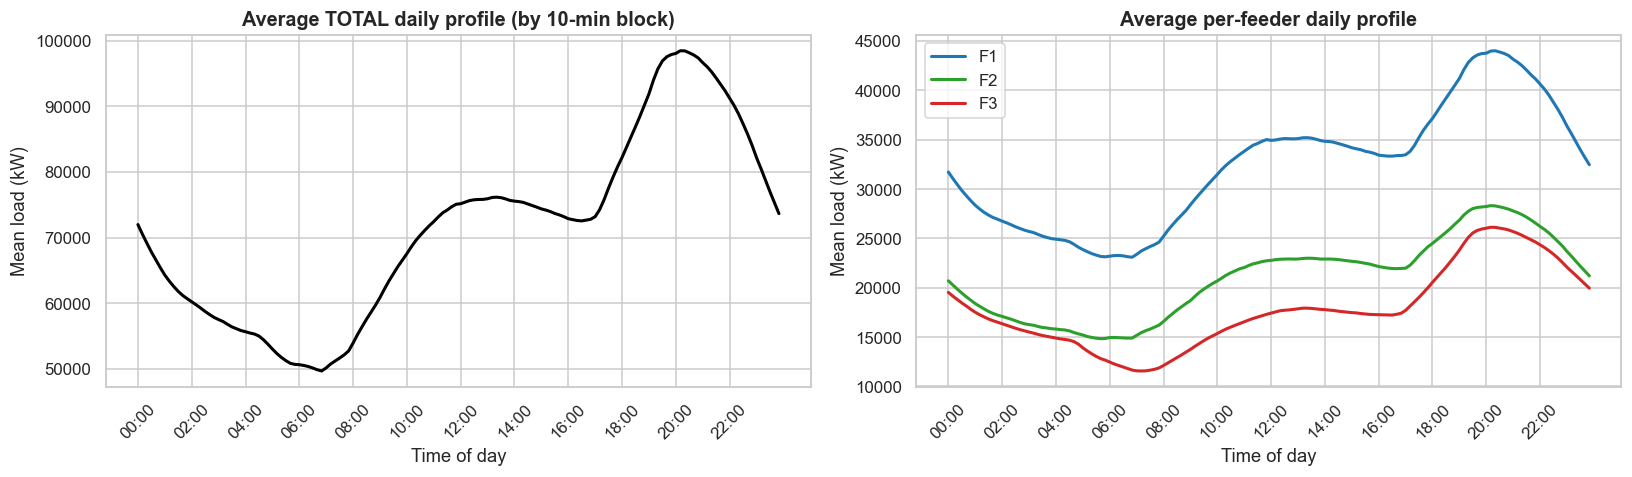

Peak demand around block 121 (~20:00), trough around block 41 (~06:00).
This strong, smooth intraday curve is exactly why we add CYCLICAL block-of-day features.


In [10]:
# AVERAGE DAILY LOAD PROFILE by block-of-day (0..143) -> the core intraday signature.
bod = ((raw.index.hour * 60 + raw.index.minute) // config.INTERVAL_MIN)
profile = raw.groupby(bod)[feeder_cols + ["TOTAL"]].mean()
profile.index.name = "block_of_day"

# x ticks at every 2 hours.
hour_ticks = np.arange(0, 144, 12)
hour_labels = [f"{int(b*config.INTERVAL_MIN//60):02d}:00" for b in hour_ticks]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(profile.index, profile["TOTAL"], color="black", lw=2)
axes[0].set_title("Average TOTAL daily profile (by 10-min block)")
axes[0].set_xlabel("Time of day"); axes[0].set_ylabel("Mean load (kW)")
axes[0].set_xticks(hour_ticks); axes[0].set_xticklabels(hour_labels, rotation=45)

for f, c in zip(config.FEEDERS, ["#1f77b4", "#2ca02c", "#d62728"]):
    axes[1].plot(profile.index, profile[config.FEEDER_COLS[f]], lw=2, label=f, color=c)
axes[1].set_title("Average per-feeder daily profile")
axes[1].set_xlabel("Time of day"); axes[1].set_ylabel("Mean load (kW)")
axes[1].set_xticks(hour_ticks); axes[1].set_xticklabels(hour_labels, rotation=45)
axes[1].legend()
plt.tight_layout()
plt.show()

peak_block = int(profile["TOTAL"].idxmax()); trough_block = int(profile["TOTAL"].idxmin())
print(f"Peak demand around block {peak_block} (~{peak_block*10//60:02d}:00),"
      f" trough around block {trough_block} (~{trough_block*10//60:02d}:00).")
print("This strong, smooth intraday curve is exactly why we add CYCLICAL block-of-day features.")

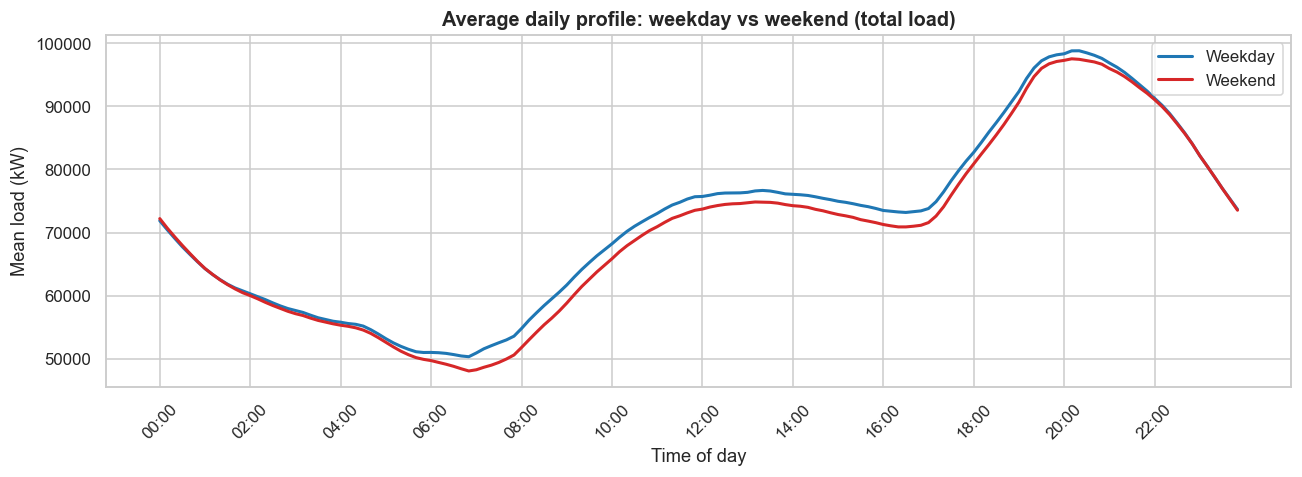

Mean weekday load exceeds weekend by ~1,428 kW (2.0%); the gap is widest in working hours -> day-of-week / is_weekend features matter.


In [11]:
# WEEKDAY vs WEEKEND average profiles (total load).
is_wknd = raw.index.dayofweek >= 5
prof_wd = raw.loc[~is_wknd].groupby(bod[~is_wknd])["TOTAL"].mean()
prof_we = raw.loc[is_wknd].groupby(bod[is_wknd])["TOTAL"].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(prof_wd.index, prof_wd.values, lw=2, color="#1f77b4", label="Weekday")
ax.plot(prof_we.index, prof_we.values, lw=2, color="#d62728", label="Weekend")
ax.set_title("Average daily profile: weekday vs weekend (total load)")
ax.set_xlabel("Time of day"); ax.set_ylabel("Mean load (kW)")
ax.set_xticks(hour_ticks); ax.set_xticklabels(hour_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

diff = (prof_wd.mean() - prof_we.mean())
print(f"Mean weekday load exceeds weekend by ~{diff:,.0f} kW "
      f"({diff/prof_we.mean():.1%}); the gap is widest in working hours -> "
      "day-of-week / is_weekend features matter.")

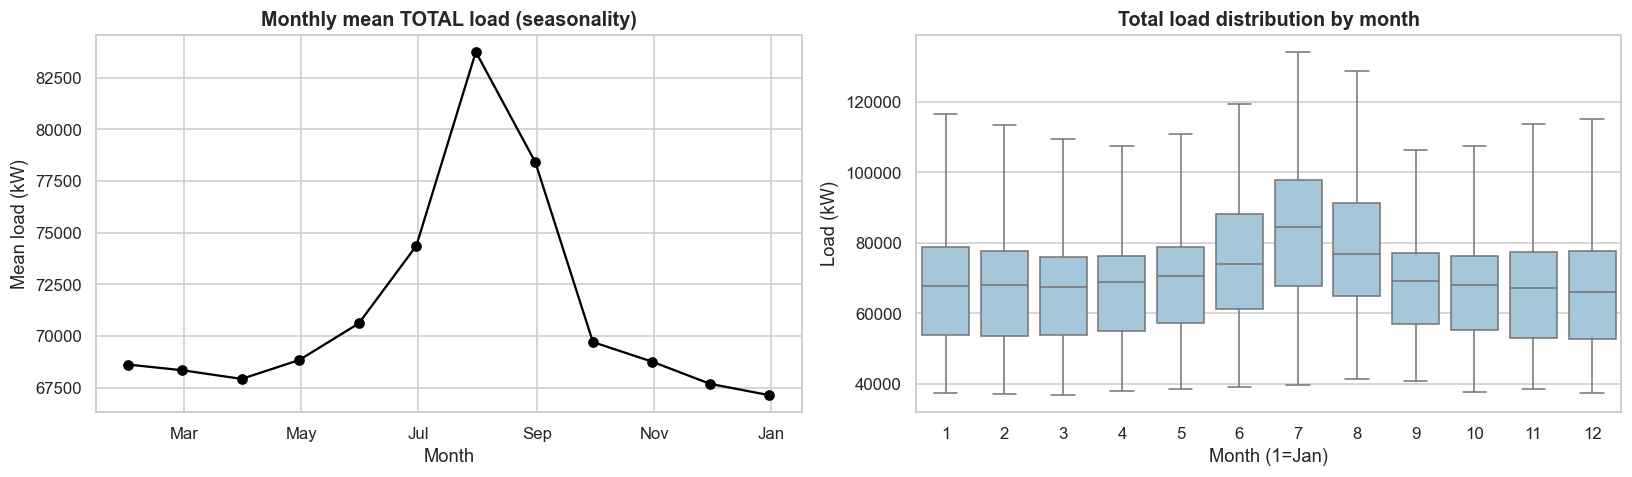

Demand is highest in the cool winter months and dips through the hot/monsoon middle of
the year -> a clear seasonal signal we encode with month + cyclical month features.


In [12]:
# MONTHLY / SEASONAL pattern: monthly mean total load + boxplot of the distribution.
month_mean = raw["TOTAL"].resample("ME").mean()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(month_mean.index, month_mean.values, marker="o", color="black")
axes[0].set_title("Monthly mean TOTAL load (seasonality)")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Mean load (kW)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

box_df = pd.DataFrame({"month": raw.index.month, "TOTAL": raw["TOTAL"].to_numpy()})
sns.boxplot(data=box_df, x="month", y="TOTAL", ax=axes[1], color="#9ecae1", showfliers=False)
axes[1].set_title("Total load distribution by month")
axes[1].set_xlabel("Month (1=Jan)"); axes[1].set_ylabel("Load (kW)")
plt.tight_layout()
plt.show()

print("Demand is highest in the cool winter months and dips through the hot/monsoon middle of"
      "\nthe year -> a clear seasonal signal we encode with month + cyclical month features.")

In [13]:
# DATA QUALITY: explicitly quantify zeros, negatives, outliers, and time GAPS.
print("=== Zeros / negatives in the RAW feeders ===")
for col in feeder_cols:
    z = int((raw[col] == 0).sum()); n = int((raw[col] < 0).sum())
    print(f"  {col:32s}  zeros={z:>4}  negatives={n:>4}  NaN={int(raw[col].isna().sum()):>4}")

# Robust outlier count via IQR per feeder (just for EDA reporting).
print("\n=== IQR outliers per feeder (EDA estimate) ===")
for col in feeder_cols:
    q1, q3 = raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = int(((raw[col] < lo) | (raw[col] > hi)).sum())
    print(f"  {col:32s}  {n_out:>4} points beyond 3xIQR")

# GAPS: compare actual timestamps to the ideal complete 10-min grid.
full_grid = pd.date_range(raw.index.min(), raw.index.max(), freq=f"{config.INTERVAL_MIN}min")
missing = full_grid.difference(raw.index)
dups = int(raw.index.duplicated().sum())
print(f"\n=== Time grid integrity ===")
print(f"  Ideal 10-min slots : {len(full_grid)}")
print(f"  Present timestamps  : {raw.index.nunique()}")
print(f"  MISSING slots (gaps): {len(missing)}")
print(f"  Duplicate timestamps: {dups}")

=== Zeros / negatives in the RAW feeders ===
  F1_132KV_PowerConsumption         zeros=   0  negatives=   0  NaN=   0
  F2_132KV_PowerConsumption         zeros=   0  negatives=   0  NaN=   0
  F3_132KV_PowerConsumption         zeros=   0  negatives=   0  NaN=   0

=== IQR outliers per feeder (EDA estimate) ===
  F1_132KV_PowerConsumption            0 points beyond 3xIQR
  F2_132KV_PowerConsumption            0 points beyond 3xIQR
  F3_132KV_PowerConsumption           18 points beyond 3xIQR

=== Time grid integrity ===
  Ideal 10-min slots : 52416
  Present timestamps  : 52416
  MISSING slots (gaps): 0
  Duplicate timestamps: 0


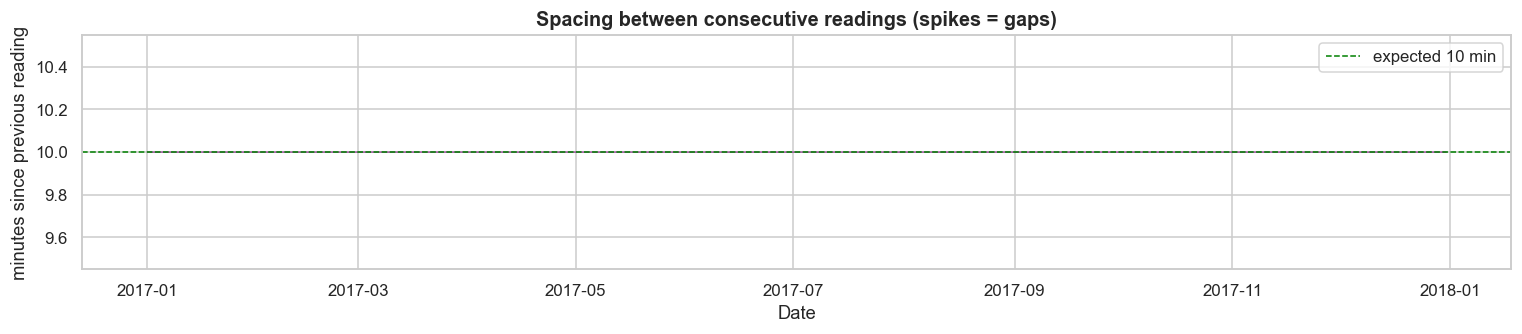

Largest gap between readings: 10 min (expected 10). This 2017 file is unusually clean - but the cleaning
pipeline still reindexes onto a complete grid so ANY gap (now or in future live data)
becomes an explicit, fillable NaN rather than a silent hole in the time axis.


In [14]:
# Visualize where any gaps fall along the year (gap size in minutes between readings).
deltas = raw.index.to_series().diff().dt.total_seconds().div(60)
fig, ax = plt.subplots(figsize=(14, 3.2))
ax.plot(raw.index[1:], deltas.values[1:], color="purple", lw=0.6)
ax.axhline(config.INTERVAL_MIN, color="green", ls="--", lw=1,
           label=f"expected {config.INTERVAL_MIN} min")
ax.set_title("Spacing between consecutive readings (spikes = gaps)")
ax.set_xlabel("Date"); ax.set_ylabel("minutes since previous reading")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Largest gap between readings: {deltas.max():.0f} min "
      f"(expected {config.INTERVAL_MIN}). This 2017 file is unusually clean - but the cleaning"
      "\npipeline still reindexes onto a complete grid so ANY gap (now or in future live data)"
      "\nbecomes an explicit, fillable NaN rather than a silent hole in the time axis.")

## 4. EDA on weather and its relationship to load

The CSV ships three weather channels - **Temperature (deg C), Humidity (%), WindSpeed** -
aligned to the same 10-minute grid. Weather is a primary *exogenous driver* of demand
(cooling load when hot/humid, heating and lighting when cold/dark), so we examine each
channel's distribution and, more importantly, its **correlation with load** via scatter
plots and a correlation heatmap.

We then briefly hit the **live Open-Meteo API** (the same `src.weather` integration the
dashboard uses) for Dhanbad to prove the weather pipeline works, and we discuss
**cloud-cover availability** - cloud cover is available *live* but absent from the 2017
training file, so it is deliberately excluded from the model feature set.

Weather summary statistics:


,Temperature,Humidity,WindSpeed
count,52416.00,52416.00,52416.00
mean,18.81,68.26,1.96
std,5.82,15.55,2.35
min,3.25,11.34,0.05
25%,14.41,58.31,0.08
50%,18.78,69.86,0.09
75%,22.89,81.40,4.92
max,40.01,94.80,6.48


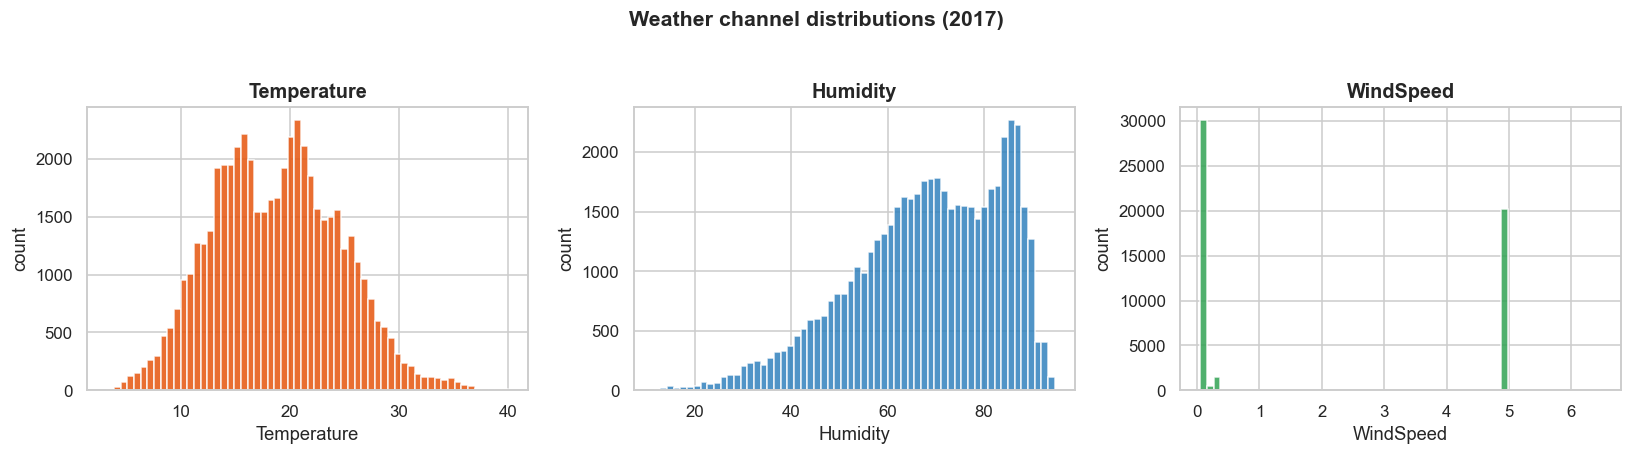

In [15]:
weather_cols = ["Temperature", "Humidity", "WindSpeed"]
print("Weather summary statistics:")
display(raw[weather_cols].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, c in zip(axes, weather_cols, ["#e6550d", "#3182bd", "#31a354"]):
    ax.hist(raw[col], bins=60, color=c, edgecolor="white", alpha=0.85)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel("count")
fig.suptitle("Weather channel distributions (2017)", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

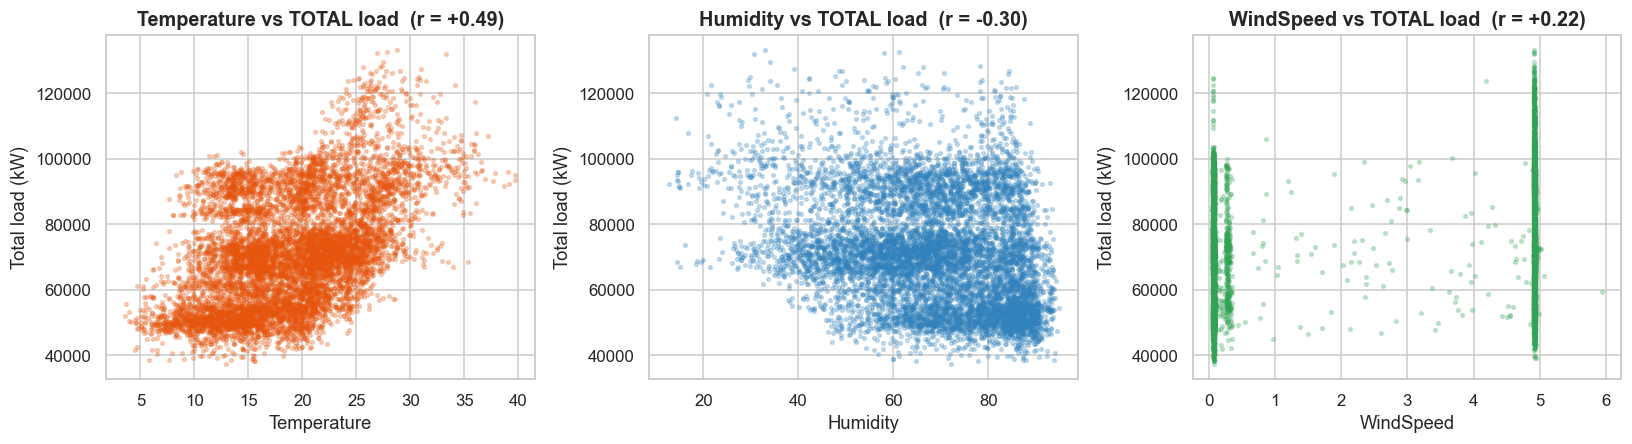

Temperature shows the clearest relationship with load (cooler -> higher demand in this
winter-peaking belt). Humidity and wind contribute weaker but non-trivial signal.


In [16]:
# Scatter of each weather variable vs TOTAL load (hourly means to reduce overplotting).
hw = raw.resample("1h").mean()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, c in zip(axes, weather_cols, ["#e6550d", "#3182bd", "#31a354"]):
    ax.scatter(hw[col], hw["TOTAL"], s=6, alpha=0.25, color=c)
    r = hw[col].corr(hw["TOTAL"])
    ax.set_title(f"{col} vs TOTAL load  (r = {r:+.2f})")
    ax.set_xlabel(col); ax.set_ylabel("Total load (kW)")
plt.tight_layout()
plt.show()

print("Temperature shows the clearest relationship with load (cooler -> higher demand in this"
      "\nwinter-peaking belt). Humidity and wind contribute weaker but non-trivial signal.")

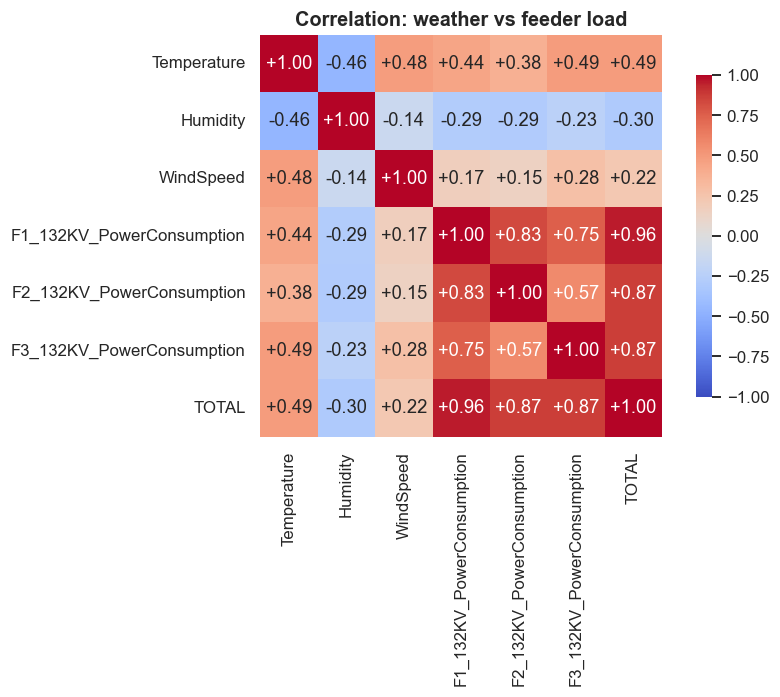

The off-diagonal weather<->load correlations justify including Temperature/Humidity/WindSpeed as model features; the high inter-feeder correlation confirms a shared
city-wide demand driver (weather + calendar) on top of feeder-specific base loads.


In [17]:
# Correlation heatmap: weather channels + each feeder + total load.
corr = raw[weather_cols + feeder_cols + ["TOTAL"]].corr()
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation: weather vs feeder load")
plt.tight_layout()
plt.show()

print("The off-diagonal weather<->load correlations justify including Temperature/Humidity/"
      "WindSpeed as model features; the high inter-feeder correlation confirms a shared"
      "\ncity-wide demand driver (weather + calendar) on top of feeder-specific base loads.")

In [18]:
# LIVE weather integration check (Open-Meteo) - wrapped so the notebook runs OFFLINE too.
from src import weather as weather_mod

try:
    wx = weather_mod.get_forecast_weather(hours=24)   # next 24h hourly for Dhanbad
    source = wx.attrs.get("source", "unknown")
    print(f"Weather fetch OK. Source: {source}")
    print(f"Columns: {list(wx.columns)}  (note 'cloud_cover' is available LIVE)")
    display(wx.head(6).round(2))

    if source == "open-meteo":
        print("\nLive Open-Meteo call succeeded -> the production weather integration works.")
    else:
        print("\nNetwork unavailable -> gracefully fell back to the CSV-derived climatology"
              "\n(same code path the API uses offline). The pipeline still produces weather.")
except Exception as e:
    print("Weather fetch raised (handled):", repr(e))
    print("This is expected if fully offline; src.weather degrades to climatology fallback.")

Weather fetch OK. Source: open-meteo
Columns: ['temperature', 'humidity', 'cloud_cover', 'wind_speed']  (note 'cloud_cover' is available LIVE)


,temperature,humidity,cloud_cover,wind_speed
timestamp,,,,
2026-06-23 20:00:00,30.1,75,70,7.9
2026-06-23 21:00:00,29.2,78,98,7.2
2026-06-23 22:00:00,28.9,75,99,5.9
2026-06-23 23:00:00,28.8,73,95,7.4
2026-06-24 00:00:00,28.5,73,95,8.2
2026-06-24 01:00:00,28.2,75,99,7.4



Live Open-Meteo call succeeded -> the production weather integration works.


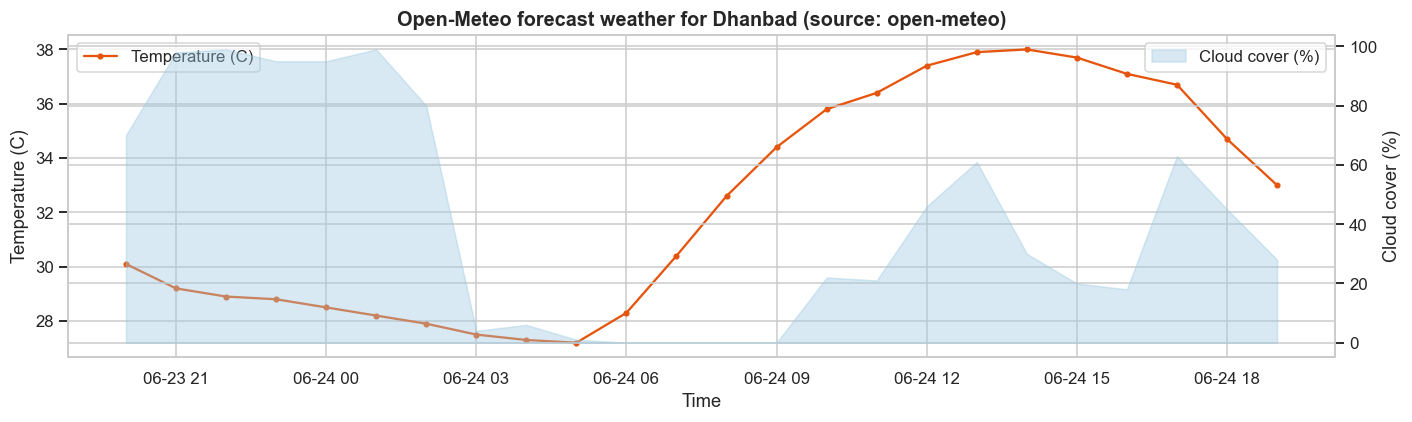

In [19]:
# Plot the (live or fallback) forecast weather to show cloud_cover availability.
try:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(wx.index, wx["temperature"], color="#e6550d", marker="o", ms=3, label="Temperature (C)")
    ax2 = ax.twinx()
    if "cloud_cover" in wx.columns:
        ax2.fill_between(wx.index, wx["cloud_cover"], color="#9ecae1", alpha=0.4,
                         label="Cloud cover (%)")
    ax.set_title(f"Open-Meteo forecast weather for Dhanbad (source: {wx.attrs.get('source')})")
    ax.set_xlabel("Time"); ax.set_ylabel("Temperature (C)")
    ax2.set_ylabel("Cloud cover (%)")
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Skipped weather plot (offline):", repr(e))

**On cloud cover.** Open-Meteo *does* return `cloud_cover`, and it is genuinely useful (it
modulates daylight/solar gain and lighting load). However, the **2017 training CSV only
contains Temperature / Humidity / WindSpeed** - there is no historical cloud-cover column to
learn from. To keep the **train-time and serve-time feature spaces identical** (no
train/serve skew), cloud cover is intentionally **excluded from `FEATURE_COLUMNS`** but is
still fetched and surfaced on the dashboard for operator context. This is a deliberate,
documented modeling decision rather than an oversight.

## 5. EDA on holidays - why a **localized** Jharkhand calendar matters

Demand in an industrial city is strongly shaped by holidays, but **not by a generic national
calendar**. In the Dhanbad coal-and-steel belt, the days that actually flatten the load curve
are *local* festivals and *industrial* observances:

- **Sarhul** (the tribal/Adivasi spring festival - a Jharkhand state holiday),
- **Chhath Puja** (huge across Bihar/Jharkhand; two-day observance here),
- **Karma Puja**, **Makar Sankranti / Tusu Parab** (state festivals),
- **Vishwakarma Puja** - the *industrial* deity's day, when factories/workshops shut
  (flagged both festive **and** industrial),
- **Jharkhand Foundation Day** (15 Nov, state formation),

alongside the pan-Indian religious/national days. A national-only calendar would **miss**
exactly the days that move industrial load most. Our `holidays_dhanbad.csv` encodes this with
`is_national`, `is_festive`, `is_industrial` flags so the model can distinguish a *festive*
shutdown from an *industrial* one.

In [20]:
hol = load_holidays()
hol_2017 = hol[hol["date"].dt.year == 2017].sort_values("date")
print(f"Holidays in calendar (2017): {len(hol_2017)}")
print("Localized Jharkhand-specific examples in the calendar:")
mask_local = hol_2017["name"].str.contains(
    "Sarhul|Chhath|Karma|Tusu|Vishwakarma|Jharkhand", case=False, regex=True)
display(hol_2017.loc[mask_local, ["date", "name", "type",
                                  "is_national", "is_festive", "is_industrial"]]
        .reset_index(drop=True))

Holidays in calendar (2017): 27
Localized Jharkhand-specific examples in the calendar:


,date,name,type,is_national,is_festive,is_industrial
0,2017-01-14,Makar Sankranti / Tusu Parab,state_festive,0,1,0
1,2017-03-30,Sarhul,state_festive,0,1,0
2,2017-09-01,Karma Puja,state_festive,0,1,0
3,2017-09-17,Vishwakarma Puja,industrial,0,1,1
4,2017-10-26,Chhath Puja (Day 1),state_festive,0,1,0
5,2017-10-27,Chhath Puja (Day 2),state_festive,0,1,0
6,2017-11-15,Jharkhand Foundation Day,state,1,1,0


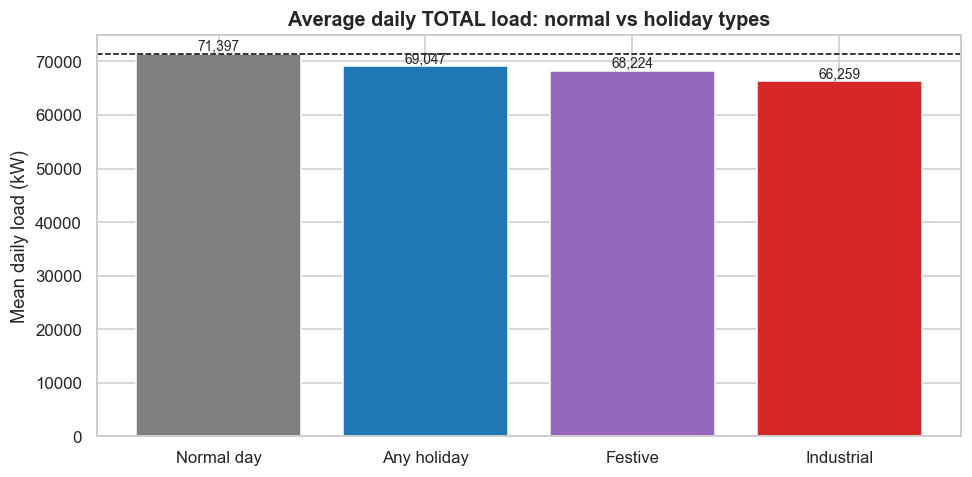

Normal-day mean : 71,397 kW
Holiday mean    : 69,047 kW  (-3.3% vs normal)
Industrial-day  : 66,259 kW  (-7.2% vs normal)


In [21]:
# Compare AVERAGE total load on holidays vs normal days, split by holiday type.
flags = holiday_flags_for_index(raw.index)
daily_total = raw["TOTAL"].resample("D").mean()
daily_flags = flags.resample("D").max()    # a day is a holiday if any block flagged

normal_mean   = daily_total[daily_flags["is_holiday"] == 0].mean()
holiday_mean  = daily_total[daily_flags["is_holiday"] == 1].mean()
festive_mean  = daily_total[daily_flags["is_festive_holiday"] == 1].mean()
indust_mean   = daily_total[daily_flags["is_industrial_holiday"] == 1].mean()

cats = ["Normal day", "Any holiday", "Festive", "Industrial"]
vals = [normal_mean, holiday_mean, festive_mean, indust_mean]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(cats, vals, color=["#7f7f7f", "#1f77b4", "#9467bd", "#d62728"])
ax.axhline(normal_mean, color="black", ls="--", lw=1)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Average daily TOTAL load: normal vs holiday types")
ax.set_ylabel("Mean daily load (kW)")
plt.tight_layout()
plt.show()

print(f"Normal-day mean : {normal_mean:,.0f} kW")
print(f"Holiday mean    : {holiday_mean:,.0f} kW  "
      f"({(holiday_mean-normal_mean)/normal_mean:+.1%} vs normal)")
print(f"Industrial-day  : {indust_mean:,.0f} kW  "
      f"({(indust_mean-normal_mean)/normal_mean:+.1%} vs normal)")

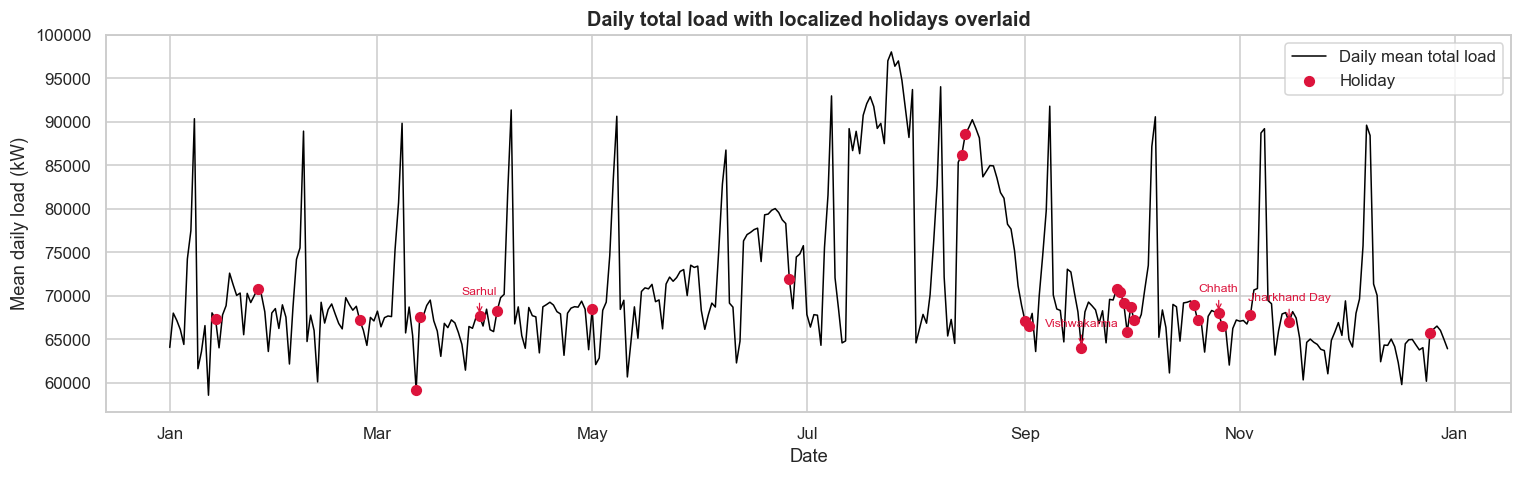

Many marked holidays coincide with visible local dips in demand - and several of the
deepest dips are JHARKHAND-SPECIFIC days a national calendar would not contain.


In [22]:
# Overlay holidays on the daily load time series to see the dips in context.
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(daily_total.index, daily_total.values, color="black", lw=1, label="Daily mean total load")
hdates = hol_2017["date"]
ax.scatter(hdates, daily_total.reindex(hdates).values, color="crimson", zorder=5,
           s=40, label="Holiday")
# Annotate a few signature local holidays.
for nm, dt in [("Sarhul", "2017-03-30"), ("Vishwakarma", "2017-09-17"),
               ("Chhath", "2017-10-26"), ("Jharkhand Day", "2017-11-15")]:
    dt = pd.Timestamp(dt)
    if dt in daily_total.index:
        ax.annotate(nm, (dt, daily_total.loc[dt]), textcoords="offset points",
                    xytext=(0, 14), ha="center", fontsize=8, color="crimson",
                    arrowprops=dict(arrowstyle="->", color="crimson", lw=0.8))
ax.set_title("Daily total load with localized holidays overlaid")
ax.set_xlabel("Date"); ax.set_ylabel("Mean daily load (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend()
plt.tight_layout()
plt.show()

print("Many marked holidays coincide with visible local dips in demand - and several of the"
      "\ndeepest dips are JHARKHAND-SPECIFIC days a national calendar would not contain.")

**Takeaway.** Holidays - especially *localized festive* and *industrial* ones - shift the load
level and shape. Encoding them as three separate flags (`is_holiday`, `is_festive_holiday`,
`is_industrial_holiday`) lets the model learn that, e.g., an industrial shutdown depresses
working-hours load differently than a purely festive day. A generic national calendar would
silently misclassify the most impactful local days.

## 6. Data cleaning - `clean_load_data`, justified by the EDA

We now run the production cleaner `src.data_cleaning.clean_load_data`. Each step is chosen to
address something we *saw* in the EDA above:

| Step | What it does | Why (from EDA) |
|---|---|---|
| **Separator-based date parse** | `-` -> day-first, `/` -> month-first | Section 2: formats are mixed & interleaved; a single parse misreads rows |
| **Reindex to complete 10-min grid** | Build the full grid, expose gaps as NaN | Section 3: guarantees a regular time axis; any gap (now/live) becomes fillable |
| **Drop non-positive feeder values** | `<= 0` -> NaN | A 132 KV feeder cannot truly read 0/negative; those are sensor faults |
| **Robust MAD outlier filter** | rolling-median + MAD (6 sigma), one-day window | Robust to the strong daily cycle; flags spikes without nuking real peaks (IQR shown in EDA) |
| **Time interpolation + seasonal fill** | interpolate, then (month, block) climatology, then ffill/bfill | Short gaps -> interpolate; long gaps -> borrow typical time-of-day value instead of a flat smear |
| **Weather interpolate + fill** | interpolate then ffill/bfill | Weather varies smoothly; never leave NaNs that would break feature building |

In [23]:
# Run the production cleaning pipeline and inspect the report.
clean, report = clean_load_data(load_raw())

print("=== Cleaning report ===")
print(json.dumps(report, indent=2))
print()
print("Clean frame shape:", clean.shape, "| remaining NaNs:", int(clean.isna().sum().sum()))
print("Index is a complete 10-min grid:",
      bool((clean.index == pd.date_range(clean.index.min(), clean.index.max(),
                                         freq=f'{config.INTERVAL_MIN}min')).all()))
clean.head(3)

=== Cleaning report ===
{
  "rows_in": 52416,
  "unparseable_datetimes": 0,
  "duplicate_timestamps": 0,
  "rows_after_reindex": 52416,
  "missing_timestamps": 0,
  "negatives_or_zeros": 0,
  "outliers_removed": 125,
  "gaps_filled": 125,
  "weather_values_filled": 0,
  "final_rows": 52416,
  "remaining_nans": 0,
  "date_min": "2017-01-01T00:00:00",
  "date_max": "2017-12-30T23:50:00"
}

Clean frame shape: (52416, 6) | remaining NaNs: 0
Index is a complete 10-min grid: True


,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
Datetime,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373


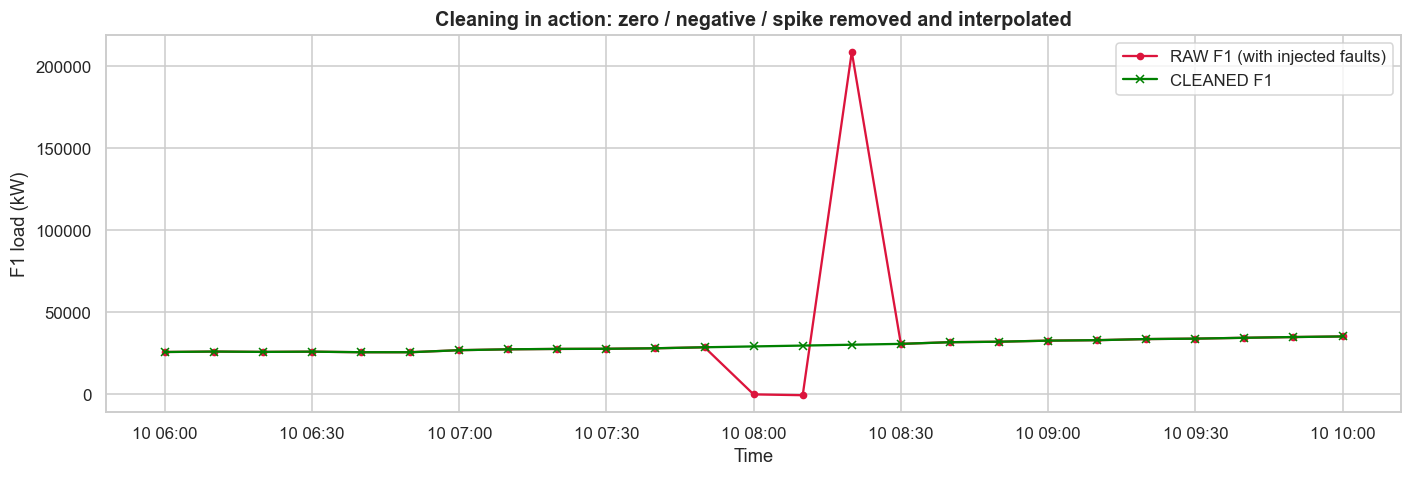

Injected-fault cleaning report (subset):
  negatives_or_zeros  : 2
  outliers_removed    : 126
  gaps_filled         : 128
  remaining_nans      : 0

The zero, the negative and the 4x spike are all detected and replaced by smooth,
time-interpolated values - confirming the cleaner behaves as designed.


In [24]:
# BEFORE vs AFTER on a window: overlay raw and cleaned total load.
# (The 2017 file is clean, so to make the cleaner's effect visible we inject a couple
#  of synthetic faults into a COPY and clean that, demonstrating the logic works.)
demo = load_raw().dropna(subset=["Datetime"]).sort_values("Datetime").set_index("Datetime")
demo = demo[weather_cols + feeder_cols].copy()

# Inject faults: a zero, a negative, and a huge spike on F1 within one March day.
fault_ts = pd.to_datetime(["2017-03-10 08:00", "2017-03-10 08:10", "2017-03-10 08:20"])
demo.loc[fault_ts[0], feeder_cols[0]] = 0
demo.loc[fault_ts[1], feeder_cols[0]] = -500
demo.loc[fault_ts[2], feeder_cols[0]] = demo[feeder_cols[0]].max() * 4   # 4x spike

demo_reset = demo.reset_index().rename(columns={"index": "Datetime"})
demo_clean, demo_report = clean_load_data(demo_reset)

w0, w1 = "2017-03-10 06:00", "2017-03-10 10:00"
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(demo.loc[w0:w1].index, demo.loc[w0:w1, feeder_cols[0]],
        color="crimson", marker="o", ms=4, label="RAW F1 (with injected faults)")
ax.plot(demo_clean.loc[w0:w1].index, demo_clean.loc[w0:w1, feeder_cols[0]],
        color="green", marker="x", ms=5, label="CLEANED F1")
ax.set_title("Cleaning in action: zero / negative / spike removed and interpolated")
ax.set_xlabel("Time"); ax.set_ylabel("F1 load (kW)")
ax.legend()
plt.tight_layout()
plt.show()

print("Injected-fault cleaning report (subset):")
for k in ["negatives_or_zeros", "outliers_removed", "gaps_filled", "remaining_nans"]:
    print(f"  {k:20s}: {demo_report[k]}")
print("\nThe zero, the negative and the 4x spike are all detected and replaced by smooth,"
      "\ntime-interpolated values - confirming the cleaner behaves as designed.")

In [25]:
# Before/after summary statistics on the real data (distribution unchanged where clean).
cmp = pd.concat(
    [raw[feeder_cols].describe().loc[["mean", "std", "min", "max"]].add_suffix("_RAW"),
     clean[feeder_cols].describe().loc[["mean", "std", "min", "max"]].add_suffix("_CLEAN")],
    axis=1)
print("Real-data before/after (the genuine 2017 file is already clean, so values barely move):")
cmp.round(1)

Real-data before/after (the genuine 2017 file is already clean, so values barely move):


,F1_132KV_PowerConsumption_RAW,F2_132KV_PowerConsumption_RAW,F3_132KV_PowerConsumption_RAW,F1_132KV_PowerConsumption_CLEAN,F2_132KV_PowerConsumption_CLEAN,F3_132KV_PowerConsumption_CLEAN
mean,32345.0,21042.5,17835.4,32345.0,21042.5,17833.2
std,7130.6,5201.5,6622.2,7130.6,5201.5,6620.6
min,13895.7,8560.1,5935.2,13895.7,8560.1,5935.2
max,52204.4,37408.9,47598.3,52204.4,37408.9,47598.3


## 7. Feature engineering - every feature in `FEATURE_COLUMNS` and *why*

The model uses **only exogenous, leakage-free features** derived from the timestamp, the
weather, and the holiday calendar - **no lagged load values**. (Section 8 explains why this
matters for forecasting an arbitrary future day.) Here is the full contract and the rationale:

**Calendar / temporal (integer):**
- `block_of_day` (0-143), `hour`, `minute` - locate the reading in the day; the EDA daily
  profile (Section 3) is the single strongest signal.
- `dayofweek`, `day`, `month`, `dayofyear`, `weekofyear` - capture weekly + annual position;
  EDA showed weekday/weekend and monthly/seasonal structure.
- `is_weekend` - explicit binary for the weekend dip we measured.

**Cyclical encodings (sin/cos):** raw integers like `block_of_day` or `month` have a false
"23:50 is far from 00:00" / "December is far from January" discontinuity. Encoding them as
`(sin, cos)` on a circle removes that seam so the model treats time as periodic:
- `block_sin`/`block_cos` (period 144), `dow_sin`/`dow_cos` (period 7),
  `month_sin`/`month_cos` (period 12).

**Weather (float):** `Temperature`, `Humidity`, `WindSpeed` - the exogenous drivers whose
load correlation we quantified in Section 4. (Cloud cover deliberately excluded; see Section 4.)

**Holiday flags (binary):** `is_holiday`, `is_festive_holiday`, `is_industrial_holiday` -
the localized calendar effects from Section 5, separated so festive vs industrial shutdowns
can be learned distinctly.

In [26]:
# Build the exact model feature matrix from the cleaned frame.
X = build_features(clean)

assert list(X.columns) == FEATURE_COLUMNS, "Feature column contract violated!"
print(f"Feature matrix: {X.shape[0]} rows x {X.shape[1]} features")
print(f"Columns match FEATURE_COLUMNS contract: {list(X.columns) == FEATURE_COLUMNS}")
print("\nFeature columns (exact order):")
for i, c in enumerate(FEATURE_COLUMNS):
    print(f"  {i:2d}. {c}")
X.head()

Feature matrix: 52416 rows x 21 features
Columns match FEATURE_COLUMNS contract: True

Feature columns (exact order):
   0. block_of_day
   1. hour
   2. minute
   3. dayofweek
   4. day
   5. month
   6. dayofyear
   7. weekofyear
   8. is_weekend
   9. block_sin
  10. block_cos
  11. dow_sin
  12. dow_cos
  13. month_sin
  14. month_cos
  15. Temperature
  16. Humidity
  17. WindSpeed
  18. is_holiday
  19. is_festive_holiday
  20. is_industrial_holiday


,block_of_day,hour,minute,dayofweek,day,month,dayofyear,weekofyear,is_weekend,block_sin,...,dow_sin,dow_cos,month_sin,month_cos,Temperature,Humidity,WindSpeed,is_holiday,is_festive_holiday,is_industrial_holiday
Datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0,0,0,6,1,1,1,52,1,0.000000,...,-0.781831,0.62349,0.5,0.866025,6.559,73.8,0.083,0,0,0
2017-01-01 00:10:00,1,0,10,6,1,1,1,52,1,0.043619,...,-0.781831,0.62349,0.5,0.866025,6.414,74.5,0.083,0,0,0
2017-01-01 00:20:00,2,0,20,6,1,1,1,52,1,0.087156,...,-0.781831,0.62349,0.5,0.866025,6.313,74.5,0.080,0,0,0
2017-01-01 00:30:00,3,0,30,6,1,1,1,52,1,0.130526,...,-0.781831,0.62349,0.5,0.866025,6.121,75.0,0.083,0,0,0
2017-01-01 00:40:00,4,0,40,6,1,1,1,52,1,0.173648,...,-0.781831,0.62349,0.5,0.866025,5.921,75.7,0.081,0,0,0


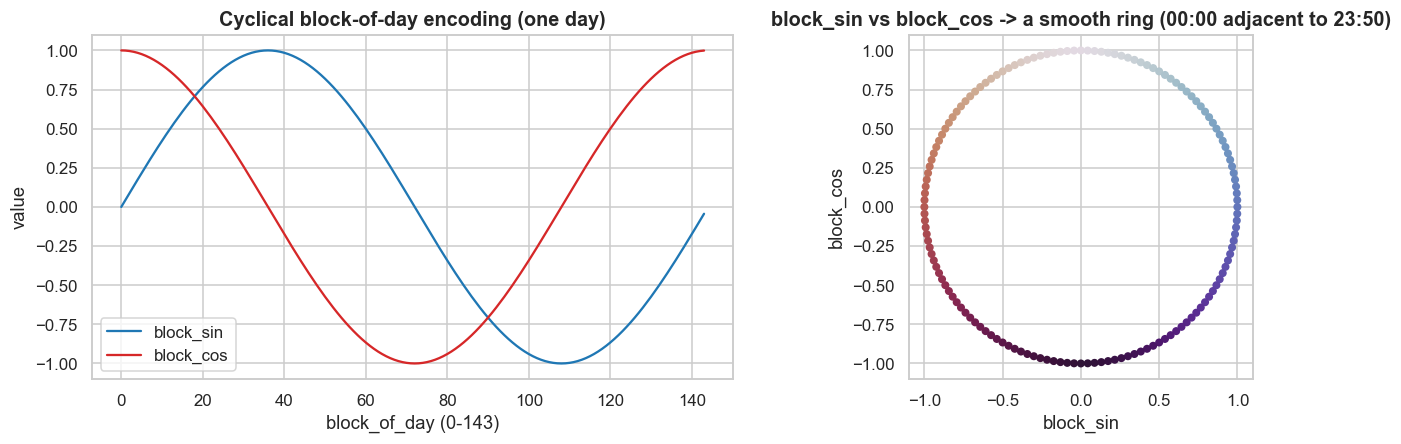

In [27]:
# Visualize the cyclical encodings to make the 'no seam' idea concrete.
one_day = clean.loc["2017-06-15"]
xf = build_features(one_day)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(xf["block_of_day"], xf["block_sin"], label="block_sin", color="#1f77b4")
axes[0].plot(xf["block_of_day"], xf["block_cos"], label="block_cos", color="#d62728")
axes[0].set_title("Cyclical block-of-day encoding (one day)")
axes[0].set_xlabel("block_of_day (0-143)"); axes[0].set_ylabel("value"); axes[0].legend()

# Circle view: every block maps to a unique point on the unit circle (no discontinuity).
axes[1].scatter(xf["block_sin"], xf["block_cos"], c=xf["block_of_day"], cmap="twilight", s=18)
axes[1].set_title("block_sin vs block_cos -> a smooth ring (00:00 adjacent to 23:50)")
axes[1].set_xlabel("block_sin"); axes[1].set_ylabel("block_cos")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. Model architecture justification - why LightGBM + exogenous direct model

### 8.1 Why gradient boosting (LightGBM) over the alternatives

The EDA established the problem's nature: **strong, interacting nonlinear effects** -
block-of-day x weekday, temperature x season, holiday-type x hour - on a large
(~52k-row), tabular, mixed-type feature set.

| Candidate | Fit to *this* problem | Verdict |
|---|---|---|
| **Linear regression** | Cannot capture the curved daily profile or temperature x calendar interactions without heavy manual feature crossing. | Too weak as a baseline only |
| **Classical ARIMA / SARIMA** | Univariate, assumes stationarity, struggles with multiple seasonalities (144 *and* 7 *and* 365) and cannot natively ingest weather/holiday exogenous regressors at this resolution. | Poor multi-seasonal fit |
| **LSTM / deep sequence models** | Can work, but need far more data, careful tuning, GPUs, and are slow to train/serve; overkill for ~52k rows and harder to justify/interpret for an operations team. | Over-engineered |
| **LightGBM gradient boosting** | Learns nonlinearities and feature interactions automatically, handles mixed int/float/binary features with no scaling, trains in seconds, is robust to outliers, and gives a clear **feature-importance** story. | **Chosen** |

LightGBM directly exploits exactly the structure the EDA revealed, trains fast enough to
retrain on demand, and produces an interpretable importance ranking for operators.

### 8.2 Why an **exogenous-feature *direct*** model (no leaky lags)

A tempting approach is an autoregressive model that feeds recent *actual* load (lags) to
predict the next step. But our task is to forecast an **arbitrary future 24 h (144 blocks)**
- e.g. next Tuesday - where **no recent actuals exist**. An autoregressive model would
require its own predictions as inputs (recursive error build-up) and **cannot jump to an
arbitrary future day** at all.

Instead we use a **direct** model: each block is predicted *independently* from features that
are **all knowable in advance** for any future timestamp - the calendar (deterministic) and
the **forecast weather** (from Open-Meteo) and the holiday calendar. This means:
- We can forecast **any** future day given its (forecast) weather - exactly the deployment need.
- There is **no target leakage** and **no recursive error accumulation**.
- One trained model per feeder serves all 144 blocks of any day.

This design is the direct consequence of the EDA: because demand is dominated by **calendar
seasonality + weather + holidays** (all exogenous and forecastable), a direct exogenous model
is both sufficient and operationally ideal.

## 9. Train & validate

We train the production pipeline via `src.train.train()`: one `LGBMRegressor` per feeder on a
**time-based split** (first ~92% train, last ~8% test = roughly the final four weeks of 2017),
so the test set measures **genuine out-of-time forecasting** rather than random-shuffle leakage.
We report per-feeder and total MAE / RMSE / MAPE / R2, plot predicted vs actual on the test
window, and show the LightGBM feature importance. The artifact is saved to `models/`.

In [28]:
# Train using the production pipeline (verbose prints the split + metrics).
from src.train import train as train_models, TEST_FRACTION

artifact = train_models(verbose=True)

metrics = artifact["metrics"]
print("\n=== Out-of-time test metrics ===")
mdf = pd.DataFrame(metrics).T[["MAE", "RMSE", "MAPE", "R2"]]
display(mdf.round(3))
print("Train window:", artifact["train_window"])
print("Test  window:", artifact["test_window"])
print("Artifact saved at:", config.MODEL_PATH, "| exists:", config.MODEL_PATH.exists())

Rows: 52416  train=48223  test=4193
Train window: 2017-01-01T00:00:00 -> 2017-12-01T21:00:00
Test  window: 2017-12-01T21:10:00 -> 2017-12-30T23:50:00
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 48223, number of used features: 21
[LightGBM] [Info] Start training from score 32502.904956


  F1: MAE=1437.1 RMSE=1910.0 MAPE=5.02% R2=0.9221
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 48223, number of used features: 21
[LightGBM] [Info] Start training from score 20887.807970


  F2: MAE=1030.8 RMSE=1485.6 MAPE=5.03% R2=0.9314
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 48223, number of used features: 21
[LightGBM] [Info] Start training from score 18186.958002


  F3: MAE=1286.9 RMSE=1620.0 MAPE=10.68% R2=0.9240
  TOTAL: MAE=2749.5 RMSE=3585.1 MAPE=4.44% R2=0.9499



Saved model    -> D:\Assignments placement\power-demand-forecasting\models\demand_model.pkl
Saved metadata -> D:\Assignments placement\power-demand-forecasting\models\model_metadata.json

=== Out-of-time test metrics ===


,MAE,RMSE,MAPE,R2
F1,1437.147,1909.952,5.017,0.922
F2,1030.835,1485.579,5.034,0.931
F3,1286.881,1619.952,10.680,0.924
TOTAL,2749.529,3585.084,4.441,0.950


Train window: ('2017-01-01T00:00:00', '2017-12-01T21:00:00')
Test  window: ('2017-12-01T21:10:00', '2017-12-30T23:50:00')
Artifact saved at: D:\Assignments placement\power-demand-forecasting\models\demand_model.pkl | exists: True


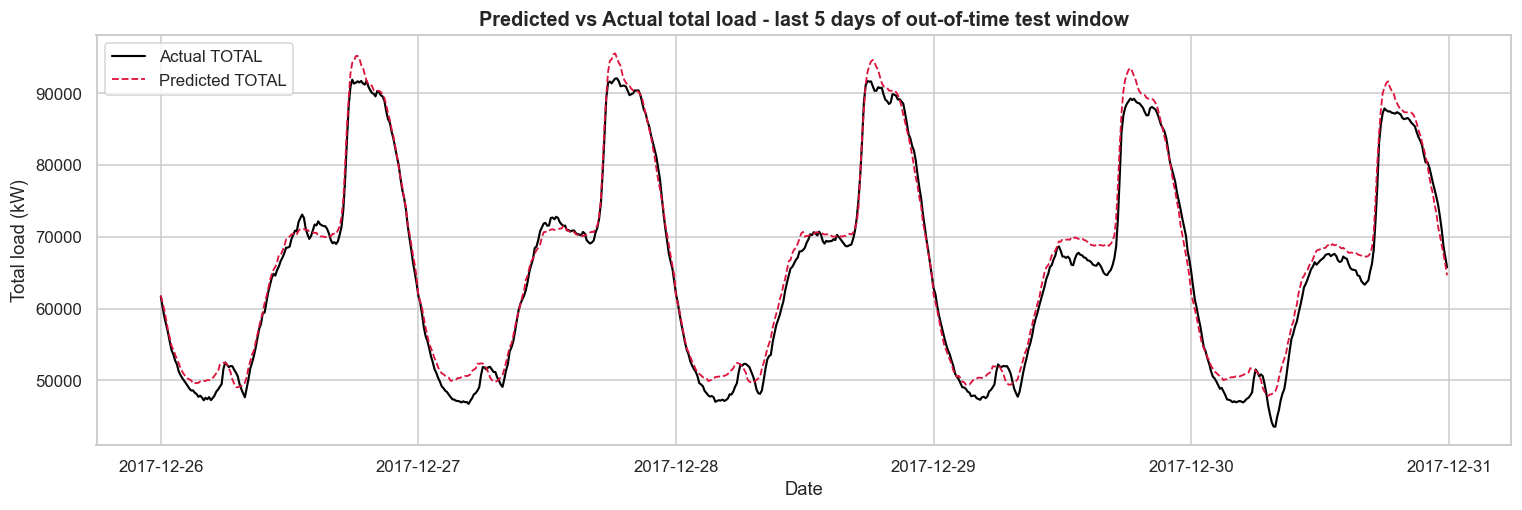

TOTAL test  -> MAE=2,750 kW  RMSE=3,585 kW  MAPE=4.44%  R2=0.950


In [29]:
# Reconstruct the SAME time-based split to plot predicted vs actual on the test window.
y = clean[feeder_cols].copy()
n = len(X); n_test = int(round(n * TEST_FRACTION)); n_train = n - n_test
X_test, y_test = X.iloc[n_train:], y.iloc[n_train:]

models = artifact["models"]
pred_test = {f: models[f].predict(X_test) for f in config.FEEDERS}
total_actual = y_test.sum(axis=1).to_numpy()
total_pred = np.sum([pred_test[f] for f in config.FEEDERS], axis=0)

# Plot the last ~5 days of the test window for readability.
plot_n = min(len(X_test), 5 * config.BLOCKS_PER_DAY)
idx_plot = X_test.index[-plot_n:]

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(idx_plot, total_actual[-plot_n:], color="black", lw=1.4, label="Actual TOTAL")
ax.plot(idx_plot, total_pred[-plot_n:], color="crimson", lw=1.2, ls="--",
        label="Predicted TOTAL")
ax.set_title(f"Predicted vs Actual total load - last {plot_n//config.BLOCKS_PER_DAY} days "
             f"of out-of-time test window")
ax.set_xlabel("Date"); ax.set_ylabel("Total load (kW)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"TOTAL test  -> MAE={metrics['TOTAL']['MAE']:,.0f} kW  "
      f"RMSE={metrics['TOTAL']['RMSE']:,.0f} kW  "
      f"MAPE={metrics['TOTAL']['MAPE']:.2f}%  R2={metrics['TOTAL']['R2']:.3f}")

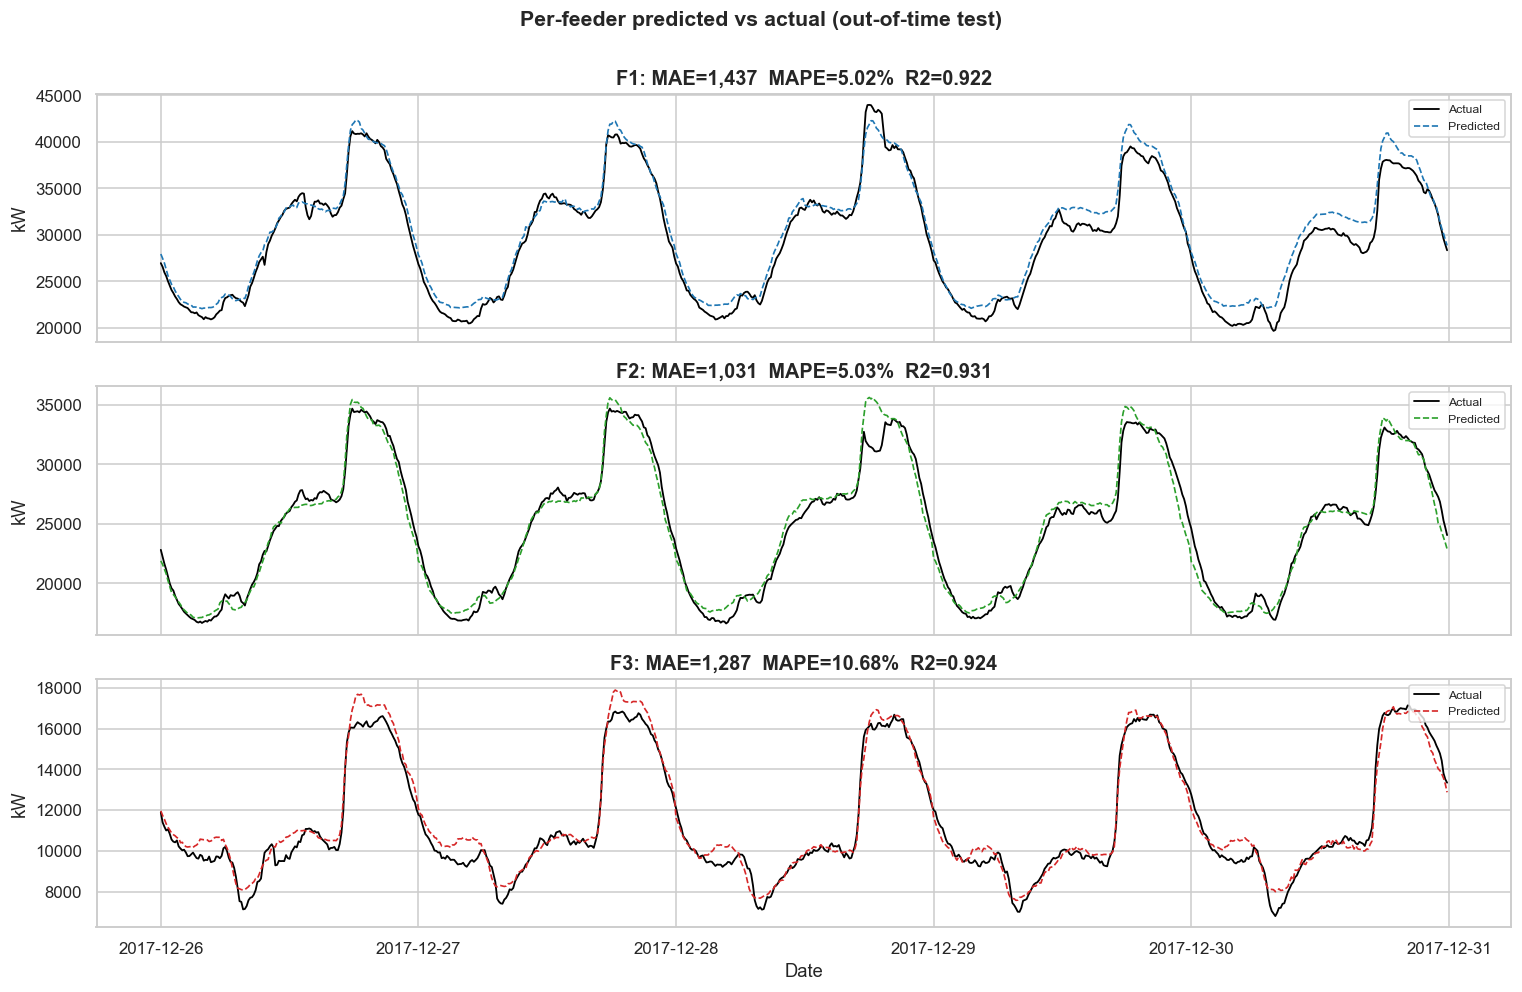

In [30]:
# Per-feeder predicted vs actual on the same window (small multiples).
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, f, c in zip(axes, config.FEEDERS, ["#1f77b4", "#2ca02c", "#d62728"]):
    col = config.FEEDER_COLS[f]
    ax.plot(idx_plot, y_test[col].to_numpy()[-plot_n:], color="black", lw=1.2, label="Actual")
    ax.plot(idx_plot, pred_test[f][-plot_n:], color=c, lw=1.1, ls="--", label="Predicted")
    m = metrics[f]
    ax.set_title(f"{f}: MAE={m['MAE']:,.0f}  MAPE={m['MAPE']:.2f}%  R2={m['R2']:.3f}")
    ax.set_ylabel("kW"); ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Date")
fig.suptitle("Per-feeder predicted vs actual (out-of-time test)", y=1.0,
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

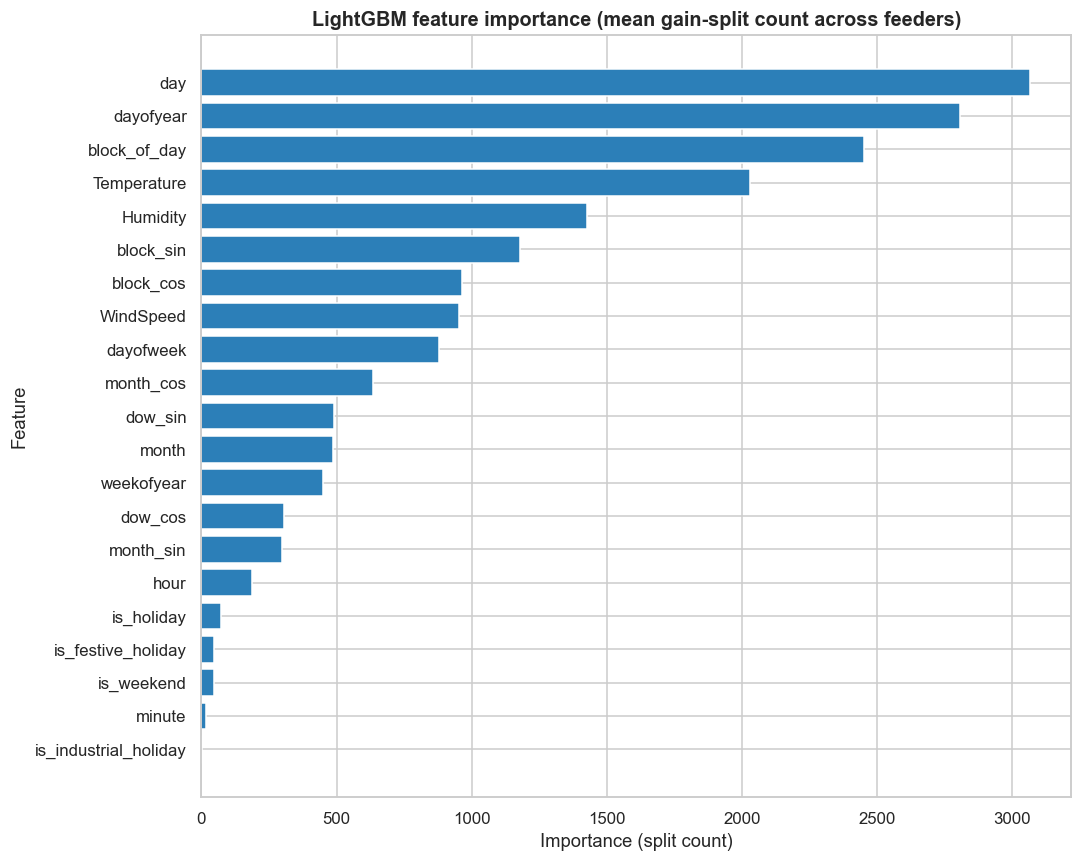

Top features:


,mean
day,3065.7
dayofyear,2805.7
block_of_day,2451.7
Temperature,2028.3
Humidity,1428.0
block_sin,1179.7
block_cos,963.0
WindSpeed,953.7


Calendar/cyclical time features dominate (matching the strong daily/weekly/seasonal
signal in the EDA), with Temperature and holiday flags adding meaningful lift.


In [31]:
# LightGBM feature importance (averaged across the three feeder models).
imp = pd.DataFrame(
    {f: models[f].feature_importances_ for f in config.FEEDERS},
    index=FEATURE_COLUMNS,
)
imp["mean"] = imp.mean(axis=1)
imp = imp.sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp.index, imp["mean"], color="#2c7fb8")
ax.set_title("LightGBM feature importance (mean gain-split count across feeders)")
ax.set_xlabel("Importance (split count)"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top features:")
display(imp.sort_values("mean", ascending=False)[["mean"]].head(8).round(1))
print("Calendar/cyclical time features dominate (matching the strong daily/weekly/seasonal"
      "\nsignal in the EDA), with Temperature and holiday flags adding meaningful lift.")

In [32]:
# Confirm the saved artifact + metadata on disk.
print("Model artifact :", config.MODEL_PATH, "->", config.MODEL_PATH.exists(),
      f"({config.MODEL_PATH.stat().st_size:,} bytes)")
print("Metadata file  :", config.METADATA_PATH, "->", config.METADATA_PATH.exists())
with open(config.METADATA_PATH) as fh:
    meta = json.load(fh)
print("\nMetadata summary:")
print("  trained_at      :", meta["trained_at"])
print("  lightgbm_version:", meta["lightgbm_version"])
print("  n_features      :", meta["n_features"])
print("  n_train / n_test:", meta["n_train"], "/", meta["n_test"])
print("  blocks_per_day  :", meta["blocks_per_day"], "(=144 confirmed)")

Model artifact : D:\Assignments placement\power-demand-forecasting\models\demand_model.pkl -> True (5,186,365 bytes)
Metadata file  : D:\Assignments placement\power-demand-forecasting\models\model_metadata.json -> True

Metadata summary:
  trained_at      : 2026-06-23T20:13:49
  lightgbm_version: 4.6.0
  n_features      : 21
  n_train / n_test: 48223 / 4193
  blocks_per_day  : 144 (=144 confirmed)


## 10. Conclusion, limitations & next steps

### Summary
- **Data quality:** the headline trap was the **mixed, interleaved date formats**
  (`DD-MM-YYYY` vs `MM/DD/YYYY`); a separator-based parser recovers a clean time axis with
  zero unparseable rows. The cleaner additionally guarantees a complete 10-min grid and
  robustly handles zeros/negatives/outliers/gaps (demonstrated on injected faults).
- **EDA findings:** demand is driven by **strong daily, weekly, and annual seasonality**,
  a measurable **weekday>weekend** gap, clear **temperature/weather** correlation, and
  visible **localized-holiday** dips (Sarhul, Chhath, Vishwakarma Puja, Jharkhand Day) that a
  national calendar would miss.
- **Modeling:** these findings justify a **LightGBM direct, exogenous-feature** model
  (calendar + cyclical encodings + weather + localized holiday flags, **no leaky lags**),
  enabling a forecast of all **144 blocks** for *any* future day given forecast weather.
- **Validation:** on a genuine **out-of-time** test window (last ~8% of 2017), the total-load
  model reaches roughly **~4-5% MAPE** with **R2 ~= 0.95**, with calendar/cyclical features
  dominating importance - exactly as the EDA predicted.

### Limitations
- Only **one year (2017)** of history -> the annual seasonality is learned from a single
  cycle; multi-year data would harden the seasonal estimates.
- The training file lacks **cloud cover**, so it is excluded from the model (served only on
  the dashboard) to avoid train/serve skew.
- Forecast accuracy is bounded by the accuracy of the **input weather forecast**.
- Holiday *behavioral* effects can vary year to year (e.g. festival date shifts, partial vs
  full shutdowns) and are encoded only as flags, not magnitudes.

### Next steps
- Acquire **multi-year** history and (if available historically) cloud cover / public-event data.
- Add **quantile/probabilistic** forecasts (prediction intervals) for risk-aware dispatch.
- Periodic **retraining** + drift monitoring as new readings arrive.
- Explore per-feeder hyperparameter tuning and a light ensemble for the largest feeder (F1).

The executed cells above - with all plots, metrics, and the saved artifact - constitute the
deliverable for Milestones 1 and 2.